# COMPOSITE Rule - SAA 기반 Grid Search 튜닝

목적함수: J_hat(w) = (1/N) sum[ w1 * Makespan/mk_ref + w2 * QV/qv_ref ]  (최소화)

- w = (alpha, beta, gamma, delta) - COMPOSITE rule의 Index Policy 선형결합 가중치 (4차원)
- 두 후보를 병렬 비교한다 (단계 0의 α=PT 결과: best에서 α=0, baseline 못 이김 → PT 신호 무용으로 판정).
  - `'WAIT_TIME'`: `-job.get_waiting_time()` — 오래 기다린 candidate가 우선 : FIFO 에서 우수하게 뽑힌 Makespan 지표 활용
  - `'CRITICAL_RATIO'`: `remain_qtime / next_PT` — slack을 next PT로 정규화한 위험 지표
- 정규화(mk_ref, qv_ref): raw Makespan/QV의 수치 범위 통일
- 가중치 weight(w1, w2): 기본 1.0, 1.0
- c_transition: transition별 실제 qtime violation을 baseline에서 측정해 위험 가중치 테이블로 사용
- CRN: replication별 고정 seed -> w 간/후보 간 공정 비교

전제: DOWN_ACTIVE=True - J_samples 분산 발생으로 t-test/SAA bias가 의미를 가진다.

구성: 1.설정 → 2.evaluator → 3.grid 탐색(α ∈ {WAIT_TIME, CRITICAL_RATIO} 병렬) → 4.두 후보 + baseline paired t-test → 5.SAA bias → 6.BO(채택 후보 기준) → 7.TODO

## 1. 환경 설정 및 데이터 로드

In [44]:
import os
import sys
import time
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# 노트북이 tuning/ 아래에 있으므로 프로젝트 루트를 sys.path에 추가
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from utils import DataLoader
from tuning.saa_evaluator import SAAEvaluator

plt.rcParams['font.family'] = ['Malgun Gothic', 'AppleGothic', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

BASE_DATA_PATH = os.path.join(PROJECT_ROOT, 'data')
data = DataLoader(BASE_DATA_PATH).load_all_data()
print(f"Jobs: {len(data['jobs'])} / Operations: {len(data['operations'])} / Machines: {len(data['machines'])}")

Jobs: 60 / Operations: 840 / Machines: 60


## 2. SAA Evaluator 초기화

초기화 시 두 가지를 자동 수행한다.

1. **transition 위험 가중치 테이블**: 여러 기존 rule(FIFO/SPT/LPT/MIN_QTIME/SPTSSU)을
   실행해 transition별 실제 qtime violation을 집계, 최댓값 정규화 -> [0,1] 테이블.
   priority 모듈에 주입되어 c_transition 항이 이 값을 조회한다.
2. **목적함수 정규화 기준 (mk_ref, qv_ref)**: reference_w=(1,1,1,1)로 COMPOSITE를
   n_ref회 실행한 평균. 정규화가 올바르면 COMPOSITE(1,1,1,1)의 J_hat은 w1+w2=2.0.

In [45]:
N_REF = 5                      # 정규화 기준 mk_ref, qv_ref 산출용 replication 수
OBJ_WEIGHTS = (1.0, 1.0)       # (w1, w2): Makespan 항 : QV 항 = 1:1
DOWN_ACTIVE = True             # True면 Machine.down 활성 -> J_samples 분산 발생 (t-test/SAA bias 의미)

evaluator = SAAEvaluator(
    data,
    reference_w=(1.0, 1.0, 1.0, 1.0),
    n_ref=N_REF,
    obj_weights=OBJ_WEIGHTS,
    base_seed=0,
    down_active=DOWN_ACTIVE,
    pm_active=False,
)
_s = evaluator.summary()
print('transition 위험 가중치 테이블:')
for t, v in sorted(_s['transition_risk'].items(), key=lambda x: -x[1]):
    print(f'  {t}: {v:.4f}')
print(f"\nmk_ref = {_s['mk_ref']:.1f}")
print(f"qv_ref = {_s['qv_ref']:.1f}")
print(f"obj_weights (w1, w2) = {_s['obj_weights']}")
print(f"DOWN_ACTIVE = {DOWN_ACTIVE}")

_chk = evaluator.evaluate((1.0, 1.0, 1.0, 1.0), n_runs=N_REF)
print(f"\nCOMPOSITE(1,1,1,1) J_hat = {_chk['J_hat']:.4f}  (기대 ~ w1+w2 = {sum(OBJ_WEIGHTS):.1f}, se={_chk['se']:.4f})")


transition 위험 가중치 테이블:
  G1->G4: 1.0000
  G1->G3: 0.3872

mk_ref = 11293.4
qv_ref = 22971.0
obj_weights (w1, w2) = (1.0, 1.0)
DOWN_ACTIVE = True

COMPOSITE(1,1,1,1) J_hat = 2.0000  (기대 ~ w1+w2 = 2.0, se=0.1374)


## 3. Grid Search — α ∈ {WAIT_TIME, CRITICAL_RATIO} 병렬 (Dirichlet 균등 격자)

각 weight를 0/K, 1/K, ..., K/K로 두고 **합=1인 조합만** 채택하는 simplex 위의 균등 격자(Dirichlet lattice).

**근거**

- COMPOSITE는 candidate 내 min-max 정규화 후 선형결합 → 절대 스케일이 아니라 **상대 비율**만 의미가 있다. `c·(α,β,γ,δ)`는 같은 dispatch를 만든다.
- 따라서 sum=1 simplex로 자유도를 하나 줄여도 일반성을 잃지 않는다.
- log/linear 임의성 없이 **균등 분할**이라 후보 정당화가 명확하고, 0(해당 항 끄기)과 corner(특정 항만 사용)가 자연 포함된다.

**점 수 공식**: C(K+DIM-1, DIM-1) — DIM=4, K=5 → 56점.

| K | 분할 단계 | 점 수 |
|---|---|---|
| 4 | {0, .25, .5, .75, 1} | 35 |
| **5** | **{0, .2, .4, .6, .8, 1}** | **56** (현 기본) |
| 6 | {0, 1/6, ..., 1} | 84 |

**탐색 비용** = 점 수 × N_RUNS × **후보 수(2)**. K=5, N_RUNS=10 → 56 × 10 × 2 = 1120 runs.

### α 후보 두 개

| 후보 | env 값 | 정의 | 부호 | 가설 |
|---|---|---|---|---|
| **WAIT_TIME** | `'WAIT_TIME'` | `-job.get_waiting_time()` | 클수록 우선 (음수로 반환) | FIFO 일관성. 오래 기다린 job → 큐 평탄화 → G1→G4 위반 감소 |
| **CRITICAL_RATIO** | `'CRITICAL_RATIO'` | `remain_qtime / next_PT` | 작을수록 우선 | slack을 next PT로 정규화. 여유 대비 다음 작업이 길수록 위험 |

CR의 None(qtime=inf) 처리: `_min_max_norm_skip_none` 자동 적용 → 모집단 제외, norm=1.0(최후순위).

- 장시간 실행 시 JupyterLab 권장 (VS Code Jupyter 소켓 타임아웃 회피)

In [ ]:
# --- Dirichlet 균등 격자 (sum=1 simplex 위의 K분할 격자) ---
# 각 weight를 0/K, 1/K, ..., K/K 중 하나로 두고, 합이 1(= K/K)인 조합만 채택.
K = 5   # 격자 해상도. 키우면 점 수 증가 (K=3:20, K=4:35, K=5:56)
DIM = 4
3:
grid = []
for c in product(range(K + 1), repeat=DIM):
    if sum(c) == K:
        grid.append(tuple(round(x / K, 6) for x in c))

ALPHA_GRID = sorted({w[0] for w in grid})
BETA_GRID  = sorted({w[1] for w in grid})
GAMMA_GRID = sorted({w[2] for w in grid})
DELTA_GRID = sorted({w[3] for w in grid})

N_RUNS = 10   # stochastic 시나리오: 각 w당 replication 수. CRN으로 w간 비교는 공정.

print(f"K={K}, DIM={DIM}")
print(f"각 축 후보값: {ALPHA_GRID}")
print(f"grid 점 수: {len(grid)}  ->  총 시뮬레이션 {len(grid) * N_RUNS}회")


K=5, DIM=4
각 축 후보값: [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
grid 점 수: 56  ->  총 시뮬레이션 560회


In [47]:
# --- grid 탐색 실행: α ∈ {WAIT_TIME, CRITICAL_RATIO} 병렬 ---

ALPHA_CANDIDATES = ['WAIT_TIME', 'CRITICAL_RATIO']
grid_dfs = {}   # {term: DataFrame}

for term in ALPHA_CANDIDATES:
    os.environ['COMPOSITE_ALPHA_TERM'] = term
    print(f"\n=== COMPOSITE_ALPHA_TERM = {term} ===")
    records = []
    t0 = time.time()
    for i, w in enumerate(grid):
        res = evaluator.evaluate(w, n_runs=N_RUNS)
        records.append({
            'alpha': w[0], 'beta': w[1], 'gamma': w[2], 'delta': w[3],
            'J_hat': res['J_hat'], 'se': res['se'],
            'makespan': res['makespan_mean'],
            'qtime_violation': res['qtime_violation_mean'],
        })
        if (i + 1) % 10 == 0 or i + 1 == len(grid):
            print(f"  [{i+1}/{len(grid)}]  elapsed {time.time()-t0:.1f}s")
    df = pd.DataFrame(records).sort_values('J_hat').reset_index(drop=True)
    grid_dfs[term] = df
    print(f"  총 소요: {time.time()-t0:.1f}s")
    print(f"  best w = (a={df.iloc[0]['alpha']:.3f}, b={df.iloc[0]['beta']:.3f}, "
          f"g={df.iloc[0]['gamma']:.3f}, d={df.iloc[0]['delta']:.3f})   "
          f"J_hat={df.iloc[0]['J_hat']:.4f}")

# 두 후보 top-5 비교
for term in ALPHA_CANDIDATES:
    print(f"\n[Top 5 — α={term}]")
    print(grid_dfs[term].head(5).to_string(index=False))


=== COMPOSITE_ALPHA_TERM = WAIT_TIME ===
  [10/56]  elapsed 89.4s
  [20/56]  elapsed 173.0s
  [30/56]  elapsed 260.0s
  [40/56]  elapsed 346.1s
  [50/56]  elapsed 433.1s
  [56/56]  elapsed 487.5s
  총 소요: 487.5s
  best w = (a=0.200, b=0.400, g=0.200, d=0.200)   J_hat=1.2524

=== COMPOSITE_ALPHA_TERM = CRITICAL_RATIO ===
  [10/56]  elapsed 146.7s
  [20/56]  elapsed 278.8s
  [30/56]  elapsed 421.5s
  [40/56]  elapsed 560.6s
  [50/56]  elapsed 696.9s
  [56/56]  elapsed 779.3s
  총 소요: 779.3s
  best w = (a=0.000, b=0.400, g=0.400, d=0.200)   J_hat=1.2653

[Top 5 — α=WAIT_TIME]
 alpha  beta  gamma  delta    J_hat       se     makespan  qtime_violation
   0.2   0.4    0.2    0.2 1.252426 0.050694 11478.974202      5420.946612
   0.0   0.4    0.4    0.2 1.265259 0.042304 11566.245582      5538.208488
   0.0   0.6    0.2    0.2 1.285373 0.057256 11677.670466      5773.611563
   0.2   0.6    0.0    0.2 1.289249 0.054181 11634.044098      5951.391429
   0.0   1.0    0.0    0.0 1.298303 0.051580 1

In [48]:
# --- 두 후보의 best_w 추출 ---
J_REF = sum(OBJ_WEIGHTS)
best_ws = {}     # {term: w-tuple}
best_rows = {}   # {term: Series}
for term in ALPHA_CANDIDATES:
    row = grid_dfs[term].iloc[0]
    best_ws[term] = tuple(round(float(row[k]), 3) for k in ['alpha', 'beta', 'gamma', 'delta'])
    best_rows[term] = row
    print(f"[α={term}]  best w = {best_ws[term]}")
    print(f"  J_hat = {round(row['J_hat'], 3)}  (se={round(row['se'], 3)})")
    print(f"  makespan = {round(row['makespan'], 3)}   qtime_violation = {round(row['qtime_violation'], 3)}")
    print(f"  reference COMPOSITE(1,1,1,1) J_hat = {J_REF:.1f}  ->  개선폭 = {round(J_REF - row['J_hat'], 3)}")
    print()

[α=WAIT_TIME]  best w = (0.2, 0.4, 0.2, 0.2)
  J_hat = 1.252  (se=0.051)
  makespan = 11478.974   qtime_violation = 5420.947
  reference COMPOSITE(1,1,1,1) J_hat = 2.0  ->  개선폭 = 0.748

[α=CRITICAL_RATIO]  best w = (0.0, 0.4, 0.4, 0.2)
  J_hat = 1.265  (se=0.042)
  makespan = 11566.246   qtime_violation = 5538.208
  reference COMPOSITE(1,1,1,1) J_hat = 2.0  ->  개선폭 = 0.735



## 3. 두 후보 + 기존 rule 비교 — Paired t-test

WAIT_TIME / CRITICAL_RATIO 각 best_w와 baseline rule들을 **같은 CRN seed 집합**으로 비교한다.

- **후보 간 직접 비교**: WAIT_TIME vs CRITICAL_RATIO 도 paired로 검정 → 더 나은 쪽을 BO에 넘긴다.

In [49]:
# --- 두 후보 best_w + baseline을 같은 CRN N_TEST=30으로 paired t-test ---
N_TEST = 30
COMPARE_RULES = ['FIFO', 'SPT', 'LPT', 'MIN_QTIME', 'SPTSSU']

J_samples = {}   # {label: ndarray of J per run}

# 각 α 후보 best_w (자기 모드에서 평가)
for term in ALPHA_CANDIDATES:
    os.environ['COMPOSITE_ALPHA_TERM'] = term
    J_samples[f'COMPOSITE({term})'] = evaluator.evaluate(best_ws[term], n_runs=N_TEST)['J_samples']

# baseline rules (α-term과 무관)
for rule in COMPARE_RULES:
    J_samples[rule] = evaluator.evaluate_rule(rule, n_runs=N_TEST)['J_samples']

# 요약 표
rows = []
for label, js in J_samples.items():
    rows.append({
        'rule': label,
        'J_mean': js.mean(),
        'J_se': js.std(ddof=1) / np.sqrt(len(js)),
    })
summary_df = pd.DataFrame(rows).sort_values('J_mean').reset_index(drop=True)
summary_df[['J_mean', 'J_se']] = summary_df[['J_mean', 'J_se']].round(4)
print(f"[N_TEST={N_TEST} CRN — 같은 seed 집합에서 평가]")
print(summary_df.to_string(index=False))

best_baseline = min(COMPARE_RULES, key=lambda r: J_samples[r].mean())
print(f"\n최강 baseline = {best_baseline}  (J_mean = {J_samples[best_baseline].mean():.4f})")

def _paired(a, b, label_a, label_b):
    diff = a - b
    print(f"\n[Paired t-test]  {label_a}  vs  {label_b}  (n={len(diff)})")
    print(f"  평균 차이 = {diff.mean():+.4f}   std = {diff.std(ddof=1):.4f}")
    if np.isclose(diff.std(ddof=1), 0.0):
        verdict = '동등(분산 없음)' if np.isclose(diff.mean(), 0.0) else (
                  '개선(결정론적 차이)' if diff.mean() < 0 else '악화(결정론적 차이)')
        print(f"  [결정론적] 판정: {verdict}")
        return
    t, p_two = stats.ttest_rel(a, b)
    p_one = p_two / 2 if t < 0 else 1.0 - p_two / 2
    print(f"  t = {t:.4f}   양측 p = {p_two:.4g}   단측 p = {p_one:.4g}")
    if p_one < 0.01: v = f'{label_a}이 매우 유의미하게 개선 (p<0.01)'
    elif p_one < 0.05: v = f'{label_a}이 유의미하게 개선 (p<0.05)'
    elif p_one < 0.10: v = '경향성만 (p<0.10)'
    else: v = '유의미한 차이 아님'
    print(f"  판정: {v}")

# 각 후보 vs 최강 baseline
for term in ALPHA_CANDIDATES:
    _paired(J_samples[f'COMPOSITE({term})'], J_samples[best_baseline],
            f'COMPOSITE({term})', best_baseline)

# 후보 간 직접 비교
_paired(J_samples[f'COMPOSITE({ALPHA_CANDIDATES[0]})'],
        J_samples[f'COMPOSITE({ALPHA_CANDIDATES[1]})'],
        f'COMPOSITE({ALPHA_CANDIDATES[0]})',
        f'COMPOSITE({ALPHA_CANDIDATES[1]})')

# 더 좋은 쪽을 BO 용 best_w / best_alpha_term 으로 노출
_better = min(ALPHA_CANDIDATES, key=lambda t: J_samples[f'COMPOSITE({t})'].mean())
best_w = best_ws[_better]
best_alpha_term = _better
best = best_rows[_better]   # SAA bias / BO 시각화 셀에서 참조
print(f"\n>>> 채택: α={best_alpha_term}   w={best_w}   (BO 단계에 인계)")

[N_TEST=30 CRN — 같은 seed 집합에서 평가]
                     rule  J_mean   J_se
COMPOSITE(CRITICAL_RATIO)  1.2416 0.0313
     COMPOSITE(WAIT_TIME)  1.2623 0.0356
                MIN_QTIME  1.2629 0.0321
                      LPT  1.5679 0.0334
                     FIFO  2.0030 0.0446
                   SPTSSU  2.6026 0.0504
                      SPT  2.7980 0.0526

최강 baseline = MIN_QTIME  (J_mean = 1.2629)

[Paired t-test]  COMPOSITE(WAIT_TIME)  vs  MIN_QTIME  (n=30)
  평균 차이 = -0.0006   std = 0.0678
  t = -0.0501   양측 p = 0.9604   단측 p = 0.4802
  판정: 유의미한 차이 아님

[Paired t-test]  COMPOSITE(CRITICAL_RATIO)  vs  MIN_QTIME  (n=30)
  평균 차이 = -0.0214   std = 0.0530
  t = -2.2071   양측 p = 0.03537   단측 p = 0.01769
  판정: COMPOSITE(CRITICAL_RATIO)이 유의미하게 개선 (p<0.05)

[Paired t-test]  COMPOSITE(WAIT_TIME)  vs  COMPOSITE(CRITICAL_RATIO)  (n=30)
  평균 차이 = +0.0208   std = 0.0568
  t = 2.0012   양측 p = 0.0548   단측 p = 0.9726
  판정: 유의미한 차이 아님

>>> 채택: α=CRITICAL_RATIO   w=(0.0, 0.4, 0.4, 0.2)   (BO 단계에 인계)

## 4. SAA Bias 관찰

SAA 이론(최소화 문제): 표본 평균으로 구한 v_N = min_w J_hat_N(w)는 아래로 편향된다.

E[v_N] <= E[v_(N+1)] <= v*

즉 N이 작을수록 grid 최소 J_hat이 낙관적(편향), N이 커지면 진짜 최적값 v*에 점차 수렴한다. 이를 관찰하려면:

- **DOWN_ACTIVE=True 전제**: 시나리오가 stochastic이어야 N에 따라 표본 평균이 변한다.
- **외부 평균**: 같은 N으로 *여러 다른 seed 묶음*을 뽑아 v_N의 분포 자체를 본다. 한 seed 묶음만 보면 단일 표본이라 편향 정도를 추정 못 함.
- **계산 비용**: grid 점수 × sum(N) × OUTER 회 시뮬레이션. N 키우면 빠르게 부담스러워지므로 grid를 좁힌다.

**BIAS_GRID는 메인 grid와 동일한 Dirichlet simplex(sum=1, 각 ∈[0,1]) 위에서 정의**한다. 메인 K=5(56점)는 bias 외부 평균을 OUTER번 반복하기엔 비싸므로 **K_BIAS=3(20점)** 으로 coarse화한다. α-term은 채택 후보(`best_alpha_term`)로 고정 — 실제 탐색에 쓰인 모드에서의 bias를 본다.

In [50]:
# --- SAA bias 관찰: 외부 OUTER번 반복하여 E[v_N]을 추정 ---
# 메인 grid와 동일한 Dirichlet simplex 위에서 BIAS_GRID 구성 (K_BIAS=3 -> 20점)
K_BIAS = 3
BIAS_GRID = []
for c in product(range(K_BIAS + 1), repeat=DIM):
    if sum(c) == K_BIAS:
        BIAS_GRID.append(tuple(round(x / K_BIAS, 6) for x in c))

BIAS_N_LIST = [2, 5, 10]
OUTER = 5

# 채택 후보의 α-term으로 고정 (실제 탐색 모드의 bias 관찰)
os.environ['COMPOSITE_ALPHA_TERM'] = best_alpha_term
print(f"BIAS α-term = {best_alpha_term}")
print(f"BIAS_GRID 점 수: {len(BIAS_GRID)} (K_BIAS={K_BIAS}, simplex)")
print(f"비용: {len(BIAS_GRID)} x sum(N) x OUTER = {len(BIAS_GRID) * sum(BIAS_N_LIST) * OUTER}회 시뮬레이션")

bias_records = []
for n in BIAS_N_LIST:
    v_outer = []
    for o in range(OUTER):
        orig_base = evaluator.base_seed
        evaluator.base_seed = orig_base + o * 10_000
        j_min = float('inf')
        for w in BIAS_GRID:
            jh = evaluator.evaluate(w, n_runs=n)['J_hat']
            if jh < j_min:
                j_min = jh
        v_outer.append(j_min)
        evaluator.base_seed = orig_base
    v_arr = np.asarray(v_outer)
    bias_records.append({
        'N': n,
        'E[v_N]': v_arr.mean(),
        'se(v_N)': v_arr.std(ddof=1) / np.sqrt(OUTER),
        'v_outer': v_arr,
    })
    print(f"N={n:3d}  E[v_N] = {v_arr.mean():.4f}  +/- {v_arr.std(ddof=1)/np.sqrt(OUTER):.4f}  "
          f"(OUTER={OUTER}회 평균)")

bias_df = pd.DataFrame([{k: r[k] for k in ['N', 'E[v_N]', 'se(v_N)']} for r in bias_records])
bias_df = bias_df.round(4)
bias_df

BIAS α-term = CRITICAL_RATIO
BIAS_GRID 점 수: 20 (K_BIAS=3, simplex)
비용: 20 x sum(N) x OUTER = 1700회 시뮬레이션
N=  2  E[v_N] = 1.3111  +/- 0.0315  (OUTER=5회 평균)
N=  5  E[v_N] = 1.3248  +/- 0.0269  (OUTER=5회 평균)
N= 10  E[v_N] = 1.3147  +/- 0.0306  (OUTER=5회 평균)


,N,E[v_N],se(v_N)
0,2,1.3111,0.0315
1,5,1.3248,0.0269
2,10,1.3147,0.0306


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

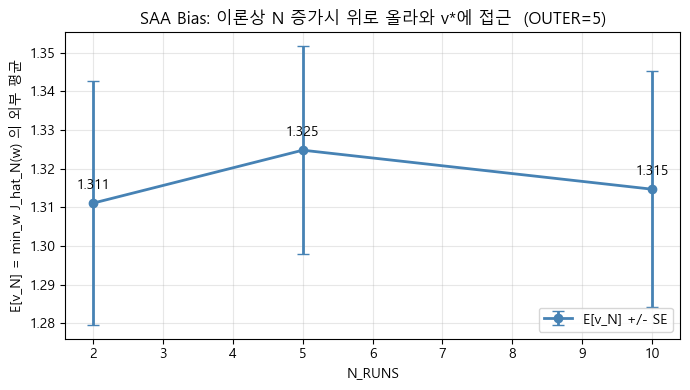

E[v_N] 단조 증가: NO - OUTER가 작아 노이즈에 가려졌을 수 있음. OUTER를 키워보라
가장 큰 N(10)에서 E[v_N] = 1.3147  -> 이 값이 v* 추정치에 가장 가깝다.


In [51]:
# --- bias 거동 시각화 (OUTER 평균 +/- SE) ---
fig, ax = plt.subplots(figsize=(7, 4))
Ns = bias_df['N'].values
means = bias_df['E[v_N]'].values
ses = bias_df['se(v_N)'].values
ax.errorbar(Ns, means, yerr=ses, fmt='o-', color='steelblue', lw=2, capsize=4, label='E[v_N] +/- SE')
for n, m in zip(Ns, means):
    ax.annotate(f"{m:.3f}", (n, m), textcoords='offset points', xytext=(0, 10), ha='center')
ax.set_xlabel('N_RUNS')
ax.set_ylabel('E[v_N] = min_w J_hat_N(w) 의 외부 평균')
ax.set_title(f'SAA Bias: 이론상 N 증가시 위로 올라와 v*에 접근  (OUTER={OUTER})')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

mono = all(means[i] <= means[i+1] + 1e-9 for i in range(len(means) - 1))
print(f"E[v_N] 단조 증가: {'YES (이론과 일치)' if mono else 'NO - OUTER가 작아 노이즈에 가려졌을 수 있음. OUTER를 키워보라'}")
print(f"가장 큰 N({Ns[-1]})에서 E[v_N] = {means[-1]:.4f}  -> 이 값이 v* 추정치에 가장 가깝다.")


## 6. Bayesian Optimization (연속 공간 미세 탐색)

grid search는 simplex 위의 K분할 격자점만 평가한다. 격자 사이의 진짜 최적은 놓칠 수 있다. 여기서는 **채택 후보(`best_alpha_term`)의 best_w 주변**을 연속 공간으로 정의하고 `gp_minimize`로 미세 탐색한다.

In [52]:
from skopt import gp_minimize
from skopt.space import Real
from skopt.plots import plot_convergence

# best_w 주변으로 탐색 공간 정의. 경계에 붙어 있으면 그쪽으로 더 넓게 연다.
def _make_space(best_w, grids):
    space = []
    names = ['alpha', 'beta', 'gamma', 'delta']
    for v, g, name in zip(best_w, grids, names):
        g_lo, g_hi = min(g), max(g)
        half = (g_hi - g_lo) / 2 if g_hi > g_lo else max(1.0, abs(v))
        lo = v - half
        hi = v + half
        # 경계 부착 시 그 방향 확장
        if v <= g_lo + 1e-9:
            lo = max(0.0, v - half)
            hi = v + 2 * half
        elif v >= g_hi - 1e-9:
            lo = max(0.0, v - 2 * half)
            hi = v + 2 * half
        lo = max(0.0, lo)
        if hi <= lo:
            hi = lo + 1.0
        space.append(Real(lo, hi, name=name))
    return space

GRIDS = [ALPHA_GRID, BETA_GRID, GAMMA_GRID, DELTA_GRID]
space = _make_space(best_w, GRIDS)
for s in space:
    print(f"  {s.name}: [{s.low:.3f}, {s.high:.3f}]")


  alpha: [0.000, 1.000]
  beta: [0.000, 0.900]
  gamma: [0.000, 0.900]
  delta: [0.000, 0.700]


In [53]:
# --- BO 실행 ---
N_CALLS = 40       # 총 평가 횟수 (initial + GP 제안)
N_INITIAL = 10     # 초기 random sampling
N_BO = N_RUNS      # 각 w 평가에 쓸 replication 수 (grid와 동일하게)

# 채택 후보의 α-term으로 고정
os.environ['COMPOSITE_ALPHA_TERM'] = best_alpha_term
print(f"BO α-term = {best_alpha_term}  (grid best w = {best_w})")

bo_history = []

def _bo_objective(w_list):
    w = tuple(float(x) for x in w_list)
    jh = evaluator.evaluate(w, n_runs=N_BO)['J_hat']
    bo_history.append({'w': w, 'J_hat': jh})
    return jh

t0 = time.time()
bo_result = gp_minimize(
    _bo_objective,
    dimensions=space,
    n_calls=N_CALLS,
    n_initial_points=N_INITIAL,
    acq_func='EI',
    random_state=0,
)
print(f"BO 소요: {time.time()-t0:.1f}s  ({N_CALLS}회 평가)")

# scale-invariance를 이용해 BO 결과를 sum=1 simplex로 정규화 (grid best와 같은 척도)
bo_raw = tuple(float(x) for x in bo_result.x)
s = sum(bo_raw)
bo_best_w = tuple(round(x / s, 3) for x in bo_raw) if s > 1e-9 else tuple(round(x, 3) for x in bo_raw)
bo_best_J = round(float(bo_result.fun), 3)
print(f"BO 최적 w (raw)        = {tuple(round(x, 3) for x in bo_raw)}  (sum={s:.3f})")
print(f"BO 최적 w (simplex 정규화) = (a={bo_best_w[0]}, b={bo_best_w[1]}, g={bo_best_w[2]}, d={bo_best_w[3]})")
print(f"J_hat = {bo_best_J}")

BO α-term = CRITICAL_RATIO  (grid best w = (0.0, 0.4, 0.4, 0.2))
BO 소요: 570.8s  (40회 평가)
BO 최적 w (raw)        = (0.0, 0.846, 0.9, 0.454)  (sum=2.200)
BO 최적 w (simplex 정규화) = (a=0.0, b=0.385, g=0.409, d=0.206)
J_hat = 1.278


In [54]:
# --- grid best vs BO best 비교 (둘 다 simplex w, α-term 동일) ---
os.environ['COMPOSITE_ALPHA_TERM'] = best_alpha_term

res_grid = evaluator.evaluate(best_w, n_runs=N_BO)
res_bo = evaluator.evaluate(bo_best_w, n_runs=N_BO)

cmp_rows = [
    {'source': 'grid best', 'w': best_w,
     'J_hat': res_grid['J_hat'], 'makespan': res_grid['makespan_mean'],
     'qtime_violation': res_grid['qtime_violation_mean']},
    {'source': 'BO best',   'w': bo_best_w,
     'J_hat': res_bo['J_hat'], 'makespan': res_bo['makespan_mean'],
     'qtime_violation': res_bo['qtime_violation_mean']},
]
cmp_df = pd.DataFrame(cmp_rows)
num_cols = ['J_hat', 'makespan', 'qtime_violation']
cmp_df[num_cols] = cmp_df[num_cols].round(3)
print(f"[α-term = {best_alpha_term}]")
print(cmp_df.to_string(index=False))

delta_J = res_grid['J_hat'] - res_bo['J_hat']
print(f"\nJ_hat 개선폭 (grid - BO) = {round(delta_J, 3)}")
print('=> BO가 격자 사이의 더 나은 점을 찾았다.' if delta_J > 1e-6
      else '=> grid best와 사실상 동등 (격자가 이미 유망 영역을 잡았다는 신호).')

[α-term = CRITICAL_RATIO]
   source                          w  J_hat  makespan  qtime_violation
grid best       (0.0, 0.4, 0.4, 0.2)  1.265 11566.246         5538.208
  BO best (0.0, 0.385, 0.409, 0.206)  1.278 11625.254         5712.090

J_hat 개선폭 (grid - BO) = -0.013
=> grid best와 사실상 동등 (격자가 이미 유망 영역을 잡았다는 신호).


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

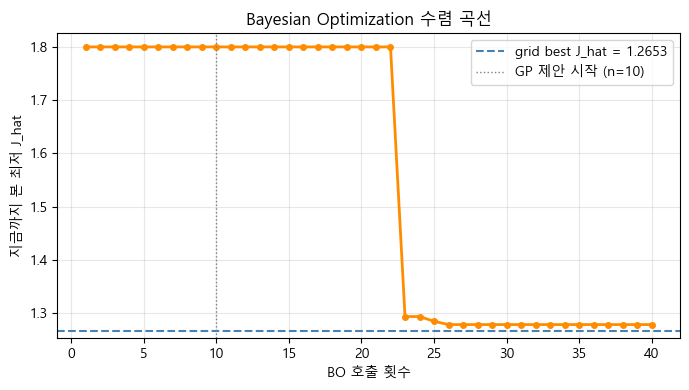

In [55]:
# --- 수렴 곡선: BO가 호출 i까지 본 최저 J_hat ---
fig, ax = plt.subplots(figsize=(7, 4))
running_min = np.minimum.accumulate([h['J_hat'] for h in bo_history])
ax.plot(range(1, len(running_min) + 1), running_min, 'o-', color='darkorange', lw=2, markersize=4)
ax.axhline(best['J_hat'], color='steelblue', ls='--', lw=1.5, label=f"grid best J_hat = {best['J_hat']:.4f}")
ax.axvline(N_INITIAL, color='gray', ls=':', lw=1, label=f'GP 제안 시작 (n={N_INITIAL})')
ax.set_xlabel('BO 호출 횟수')
ax.set_ylabel('지금까지 본 최저 J_hat')
ax.set_title('Bayesian Optimization 수렴 곡선')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
